In [1]:
import math

from scipy.io import arff
from operator import index

import numpy as np
from sklearn.metrics import roc_auc_score
from sklearn.neighbors import NearestNeighbors, KernelDensity
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from scipy import stats
from scipy.stats import expon, skew, norm, probplot
from scipy import integrate
from sklearn.metrics import auc
import seaborn as sns
import math

plt.rcParams['figure.figsize'] = [15, 7]
import warnings

warnings.filterwarnings('ignore')

In [2]:
def setupDf(fileName):
    arff_file = arff.loadarff(f'./{fileName}')
    df4 = pd.DataFrame(arff_file[0])
    if fileName[0] == 'c':
        X = df4.iloc[:,:2].values
        y = df4.iloc[:,2].values
        le = LabelEncoder()
        y = le.fit_transform(y)
    else:
        #drop the outlier and id columns for the independent variables.
        X = df4.drop(columns=['outlier','id']).values
        #get outlier values
        y = df4['outlier'].values
        le = LabelEncoder()
        #encoded the variables as 0=non-outlier, 1=outlier
        y = le.fit_transform(y)
    return X, y

def main(X, y, n):
    #find the nearestNeighbors
    nn = NearestNeighbors(n_neighbors=n)
    nn.fit(X, y)
    #return the dist of each and the nearest neighbors
    dist, knn = nn.kneighbors(X)  # returns N index neighbors including self
    return knn, dist

def generateArr(newDist, median='median'):
    arr = []
    #returns an array based on the median and max values
    for x in newDist:  # finds the distance away from that point (index 0)
        if median == 'median':
            arr += [np.median(x)]
        elif median == 'sum':  # min + median + max
            arr += [x[1] + np.max(x) + np.median(x)]
        elif median == 'max':
            arr += [np.max(x)]
        elif median == 'minMax':
            arr += [np.max(x) + x[1]]
        elif median == 'medMax':
            arr += [np.median(x) + np.max(x)]
        elif median == 'max2':
            arr += [x]

    return arr

def outputResults(X,y,lowerRange=2,upperRange=70):
    tots = []
    posNeg4 = []
    for v in range(lowerRange,upperRange):
        knn, distReturn = main(X, y, v) # index knn and the distance of each value
        distReturn = np.array(distReturn)
        arr = generateArr(distReturn, median="max")
        #arr = (arr - np.min(arr)) / (np.max(arr) - np.min(arr)) #normalize the values
        means = np.mean(arr) # exp function mean value
        arr = np.log(arr)
        inMean = 1 / means
        posNeg4 = []
        params = expon.fit(arr)
        skewed = stats.norm.fit(arr)
        #print(skewed)
        spaceStep4 = np.linspace(0,.99,30) # perform steps from .95 to .99
        for e in spaceStep4:
            #ker = -means * np.log(1 - e) # the percentile
            #f = integrate.quad(lambda x: inMean * np.exp(-x * inMean), 0, ker)
            #newArr = arr > ker # return a new array of values bigger than the percentile
            #newArr = arr > expon.ppf(e,loc=params[0],scale=params[1])
            newArr = arr > stats.expon.ppf(e,loc=params[0],scale=params[1])
            posNeg4.append([((y[newArr] == 1).sum() / (y == 1).sum()), (y[newArr] != 1).sum()/ ((y != 1).sum())])

        posNeg4 = np.array(posNeg4)
        arrtest1, arrtest2 = np.split(posNeg4, 2,axis=1) # split the array
        tots += [auc(arrtest2, arrtest1)]

    return tots

def printResults(arr):
    arr = np.nan_to_num(arr)
    arr = list(arr)
    print(max(arr),arr.index(max(arr))+2,arr) #print the max values, the k value, and the array

def goodnessOfFit(X,y,kValue):
    knn, distReturn = main(X, y, kValue) # return knn and distance
    distReturn = np.array(distReturn)
    arr = generateArr(distReturn, median="medMax") #
    print(skew(arr)) # check for skewness
    params = expon.fit(arr) # fit the arr generated and get the params
    test = np.linspace(min(arr),max(arr),10)
    # pdfTest = expon.pdf(test,params[0],params[1]) #line used to test the pdf form

    values, edges = np.histogram(arr, bins=int(np.sqrt(len(arr))), density=True) #get values from bins and the edges
    #print(values, edges)
    newX = edges[:-1] + np.diff(edges) # X values from the bins

    pdf_fitted = expon.pdf(newX, loc=params[0], scale=params[1]) # generate a new pdf using the new X values
    residuals = values - pdf_fitted # values vs the generated pdf
    print(pdf_fitted)
    #print(np.dot(residuals, residuals))
    print(sum(pow(residuals, 2) / pdf_fitted)) # prints the chi squared value
    plt.scatter(edges[:-1], values)
    plt.scatter(edges[:-1], pdf_fitted)
    plt.show()

def ksTestArr(X,y,kValue,name):
    knn, distReturn = main(X, y, kValue)
    distReturn = np.array(distReturn)
    arr = generateArr(distReturn, median="medMax")
    params = expon.fit(arr)
    results = stats.kstest(arr, expon.cdf,args=(params[0],params[1]))
    print(f"Loc: {params[0]}, scale: {params[1]}")
    print(f"stats: {results[0]}, p-value:{results[1]}")
    plt.hist(arr,bins=50)
    plt.title(name)
    plt.show()

def ksTestNorm(X,y,kValue):
    knn, distReturn = main(X, y, kValue)
    distReturn = np.array(distReturn)
    arr = generateArr(distReturn, median="medMax")
    params = stats.skewnorm.fit(arr)
    results = stats.kstest(arr, stats.skewnorm.cdf,args=(params[0],params[1],params[2]))
    print(f"stats: {results[0]}, p-value:{results[1]}")

def qqPlots(X,y,kValue, name):
    knn, distReturn = main(X, y, kValue)
    distReturn = np.array(distReturn)
    arr = generateArr(distReturn, median="medMax")
    params = stats.expon.fit(arr)
    results = probplot(arr,dist=stats.skewnorm, plot=plt,sparams=(params[0],params[1]),rvalue=True)
    plt.title(name)
    plt.show()

0.746757122393761 30 [0.732213910552284, 0.7394954639503422, 0.7340144039471589, 0.7373567563265957, 0.7391671971987905, 0.7396148336781793, 0.7419127009390419, 0.7421613878720358, 0.7400127327709694, 0.7409975330256248, 0.7408881107751074, 0.7408184784338693, 0.7411367977081013, 0.7422409676905938, 0.7423603374184308, 0.7419524908483209, 0.7400624701575682, 0.7404902116823174, 0.7409279006843865, 0.7408781632977878, 0.7421713353493555, 0.7434645074009232, 0.743673404424638, 0.7441309883813465, 0.7447278370205316, 0.7450461562947638, 0.7458519019576636, 0.7454540028648735, 0.746757122393761, 0.7457723221391056, 0.7457225847525069, 0.7450163138628044, 0.7440215661308294, 0.7439220913576318, 0.7429273436256566, 0.7451257361133218, 0.7451655260226008, 0.7467471749164413, 0.7463293808690117, 0.7454241604329143, 0.7459513767308611, 0.7455037402514723, 0.745832007003024, 0.7433948750596849, 0.7443697278370206, 0.7435440872194812, 0.7449765239535254, 0.7447377844978514, 0.7434844023555626, 0.

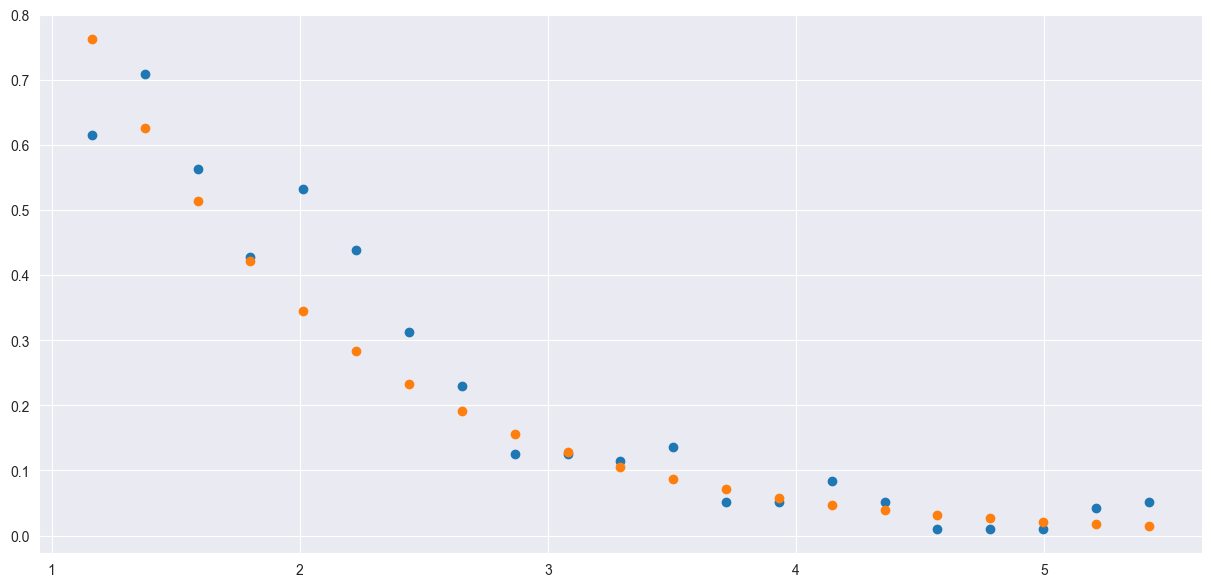

Loc: 1.1619073630269157, scale: 1.0751442795101955
stats: 0.07726700816694615, p-value:0.008772716164657171


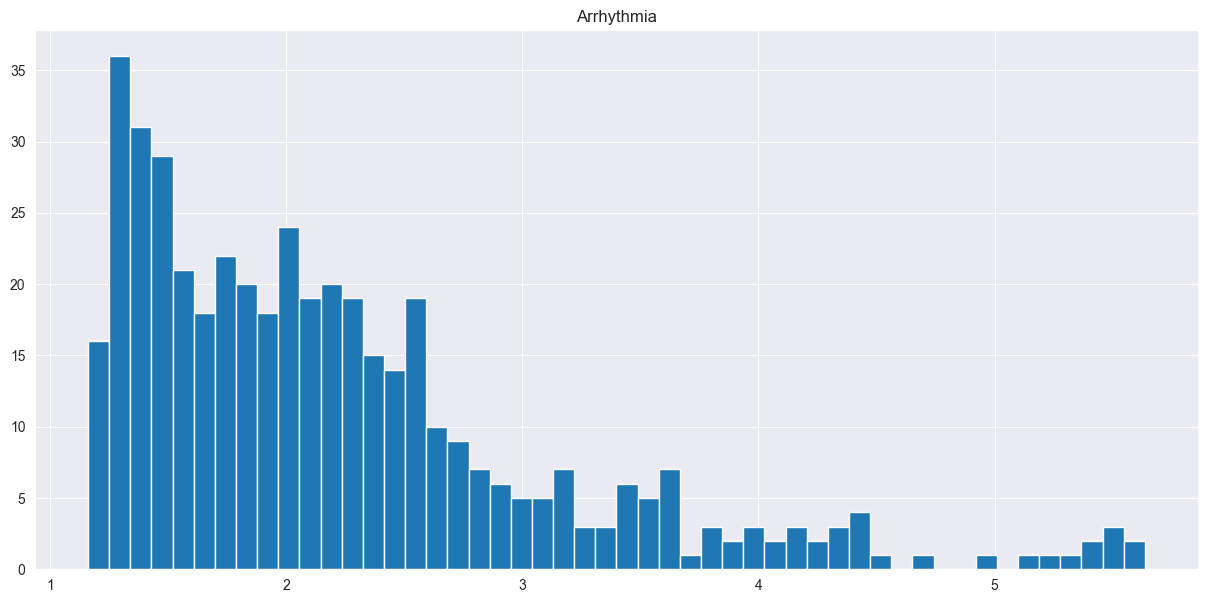

stats: 0.07462065538078666, p-value:0.012628113160247851


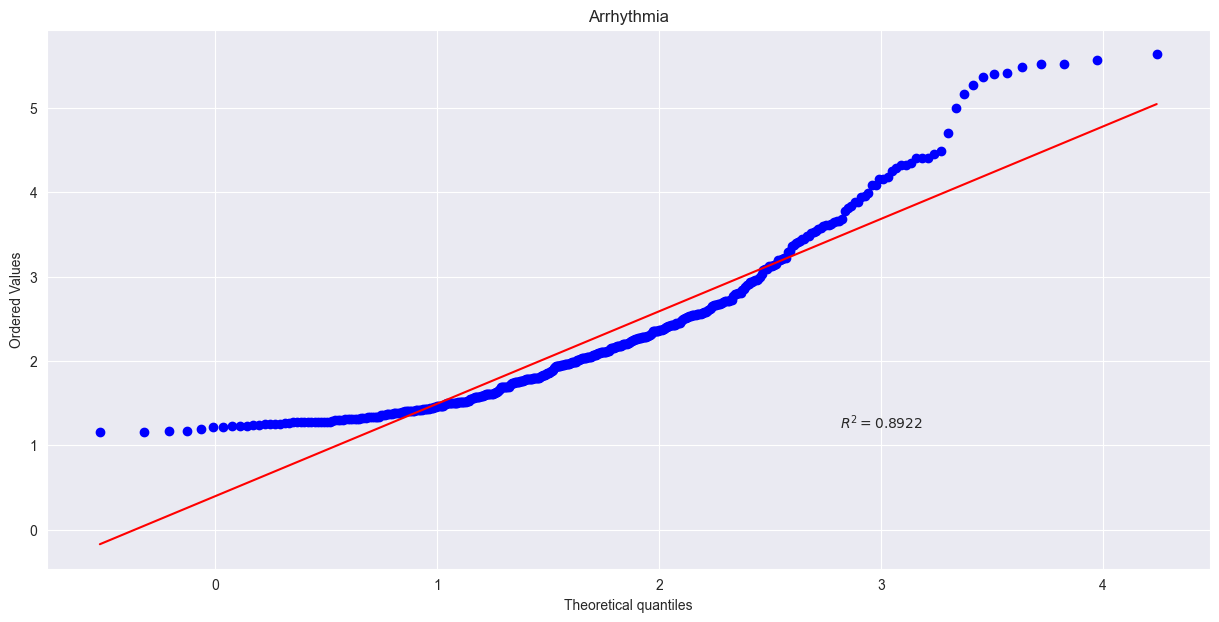

In [3]:
X, y = setupDf("real/Arrhythmia_withoutdupl_norm_46.arff")
endResults = outputResults(X,y)
printResults(endResults)
goodnessOfFit(X,y,2)
ksTestArr(X,y,2, "Arrhythmia")
ksTestNorm(X,y,2)
qqPlots(X,y,2,"Arrhythmia")

0.6315901360544217 4 [0.5836876417233561, 0.6077097505668934, 0.6315901360544217, 0.6254251700680271, 0.6308106575963719, 0.6131660997732427, 0.6251417233560089, 0.5929705215419501, 0.5778769841269842, 0.5305413832199546, 0.5423044217687074, 0.4987244897959183, 0.4840561224489795, 0.4762613378684807, 0.47704081632653056, 0.4731434240362811, 0.4870323129251701, 0.4630810657596372, 0.4614512471655328, 0.45748299319727886, 0.4756944444444444, 0.47023809523809523, 0.4733560090702948, 0.47045068027210885, 0.4658446712018141, 0.4708049886621315, 0.46598639455782315, 0.464640022675737, 0.4662698412698413, 0.4605300453514739, 0.45216836734693877, 0.45110544217687076, 0.44897959183673475, 0.4464285714285714, 0.4438066893424036, 0.4399801587301587, 0.44139739229024944, 0.4427437641723356, 0.44246031746031744, 0.4387755102040816, 0.4326814058956916, 0.4314767573696145, 0.43112244897959184, 0.4296343537414966, 0.42743764172335597, 0.4241071428571429, 0.4204931972789116, 0.4229733560090703, 0.41390

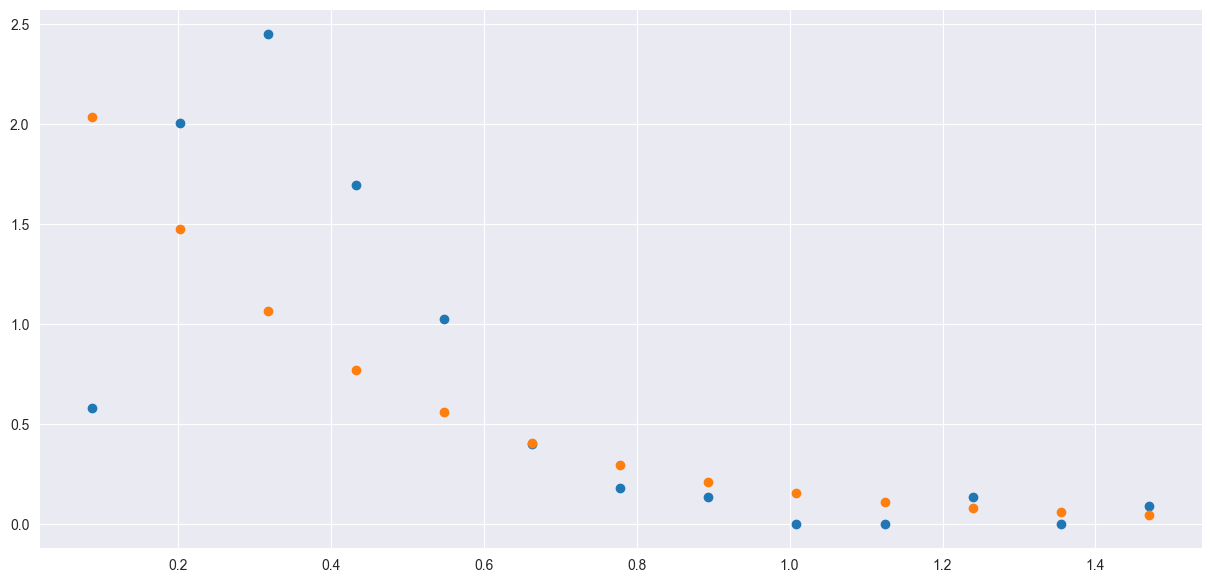

Loc: 0.08760931535152927, scale: 0.3556289537490839
stats: 0.22452888479656913, p-value:4.054999357768075e-09


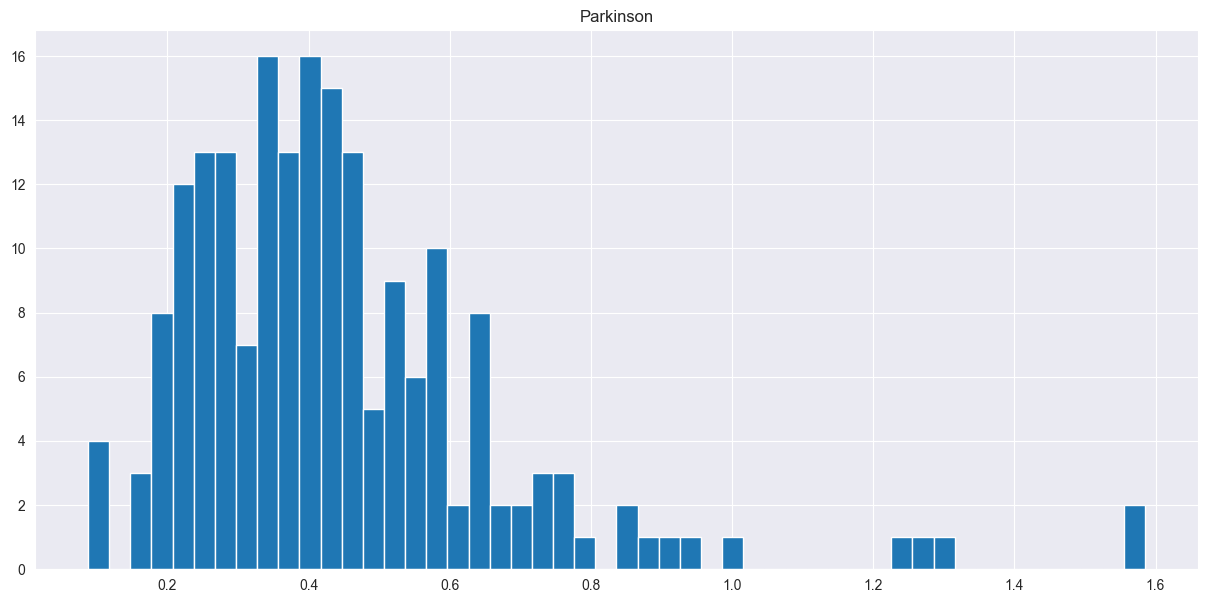

stats: 0.08431480819665882, p-value:0.11799889741962755


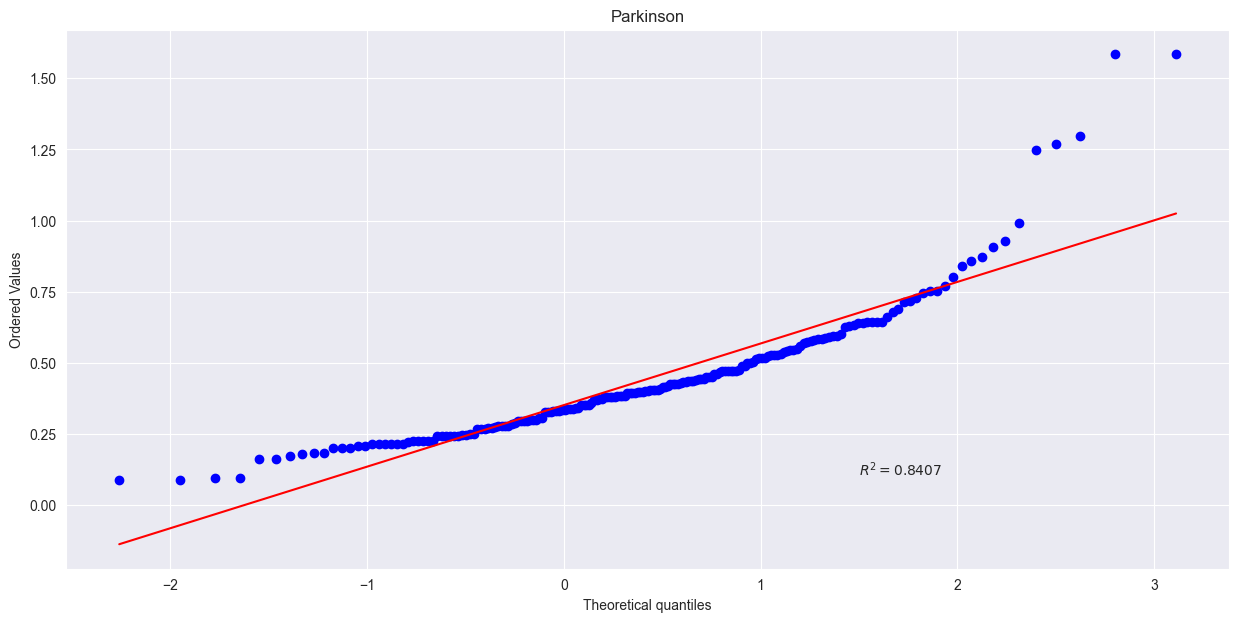

In [4]:
X, y = setupDf("real/Parkinson_withoutdupl_norm_75.arff")
endResults = outputResults(X,y)
printResults(endResults)
goodnessOfFit(X,y,2)
ksTestArr(X,y,2,"Parkinson")
ksTestNorm(X,y,2)
qqPlots(X,y,2,"Parkinson")

0.8074230769230769 5 [0.2975, 0.4252692307692308, 0.6126538461538462, 0.8074230769230769, 0.7771153846153847, 0.777, 0.7671923076923078, 0.7596153846153847, 0.744423076923077, 0.7294999999999999, 0.7278461538461538, 0.7136153846153847, 0.705076923076923, 0.7037307692307692, 0.7014615384615385, 0.7099615384615384, 0.6980000000000002, 0.7077692307692307, 0.7052307692307691, 0.7112692307692308, 0.7138461538461539, 0.7070384615384615, 0.7057307692307693, 0.7102307692307692, 0.7055769230769231, 0.7063846153846154, 0.6983076923076923, 0.6846538461538462, 0.696076923076923, 0.7020384615384615, 0.7103076923076923, 0.7105, 0.7018846153846154, 0.7041923076923077, 0.699923076923077, 0.7037692307692307, 0.7044615384615385, 0.6951923076923078, 0.6945, 0.693423076923077, 0.6885769230769232, 0.7021923076923077, 0.6991153846153847, 0.6934615384615385, 0.6925769230769231, 0.6878076923076923, 0.6873461538461539, 0.6840769230769231, 0.6843846153846154, 0.6799615384615384, 0.6706923076923076, 0.6703076923

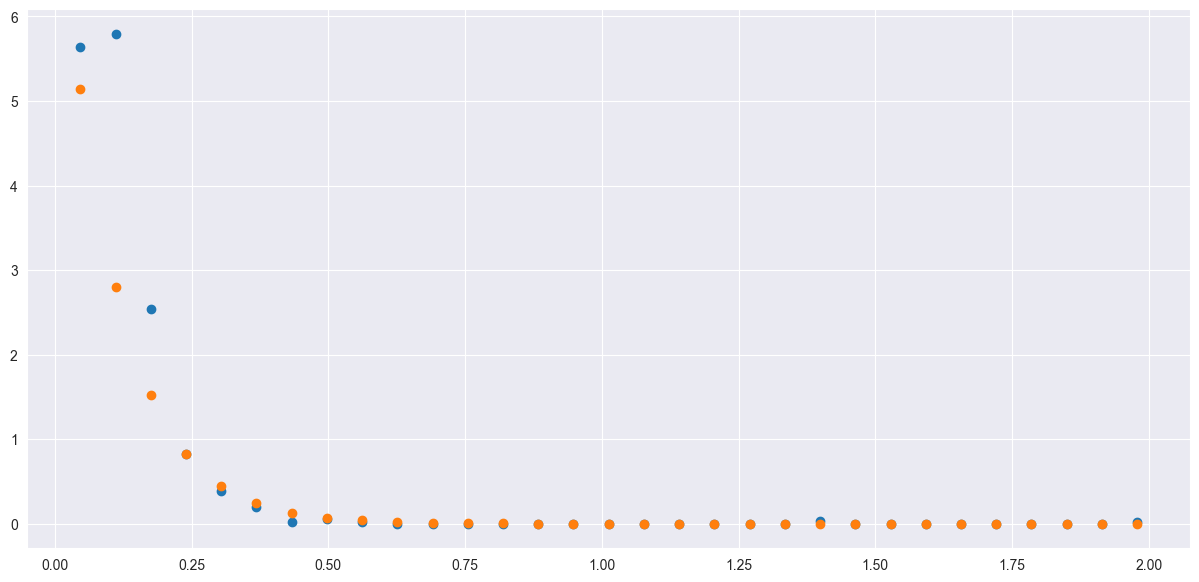

Loc: 0.046603209729096026, scale: 0.10560690329614054
stats: 0.14549924883621887, p-value:3.5239316278374557e-19


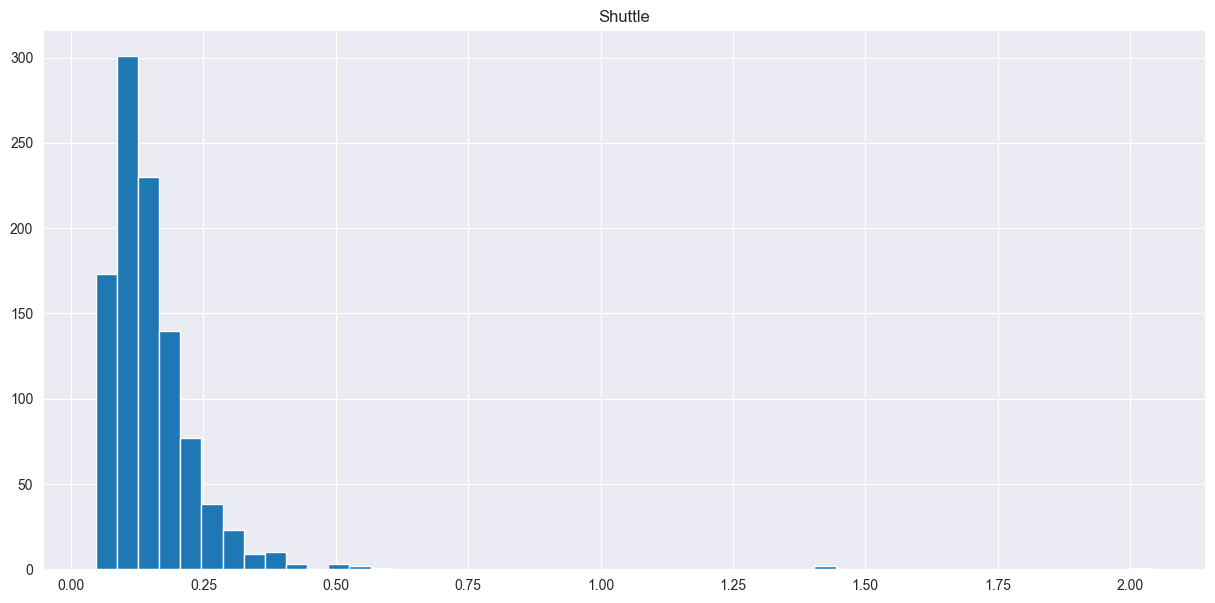

stats: 0.15062084756601357, p-value:1.5781261505498467e-20


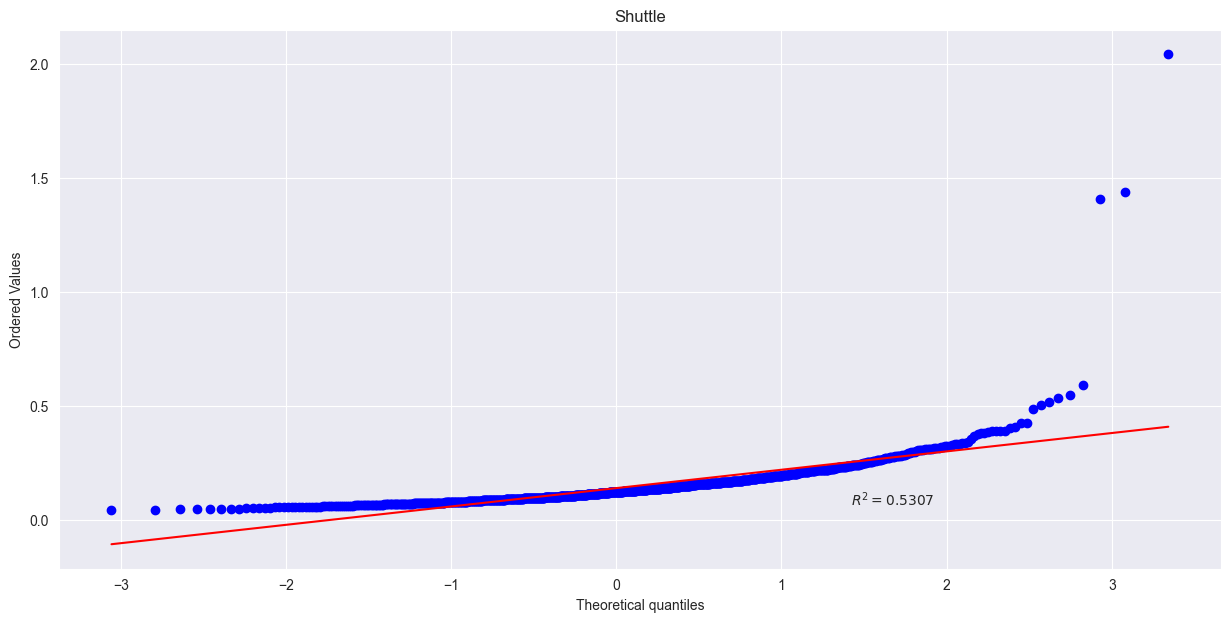

In [5]:
X, y = setupDf("real/Shuttle_withoutdupl_norm_v10.arff")
endResults = outputResults(X,y)
printResults(endResults)
goodnessOfFit(X,y,6)
ksTestArr(X,y,6,"Shuttle")
ksTestNorm(X,y,6)
qqPlots(X,y,6,"Shuttle")

0.9929577464788732 60 [0.42769953051643195, 0.6276995305164318, 0.7291079812206573, 0.8237089201877934, 0.8781690140845069, 0.9281690140845069, 0.9469483568075117, 0.9725352112676057, 0.9854460093896713, 0.7089201877934272, 0.7753521126760563, 0.8082159624413146, 0.843661971830986, 0.8694835680751174, 0.8884976525821595, 0.921361502347418, 0.9370892018779343, 0.9474178403755869, 0.9549295774647888, 0.9607981220657277, 0.9680751173708919, 0.968544600938967, 0.9746478873239437, 0.976056338028169, 0.9774647887323944, 0.9821596244131455, 0.9769953051643192, 0.9819248826291078, 0.9835680751173709, 0.9924882629107981, 0.9213615023474178, 0.9401408450704225, 0.9471830985915493, 0.9518779342723004, 0.9640845070422533, 0.9692488262910799, 0.9692488262910798, 0.973943661971831, 0.9741784037558686, 0.9741784037558685, 0.9812206572769955, 0.9816901408450704, 0.9849765258215962, 0.9830985915492958, 0.9849765258215962, 0.9849765258215961, 0.9868544600938967, 0.9903755868544601, 0.9469483568075117, 0

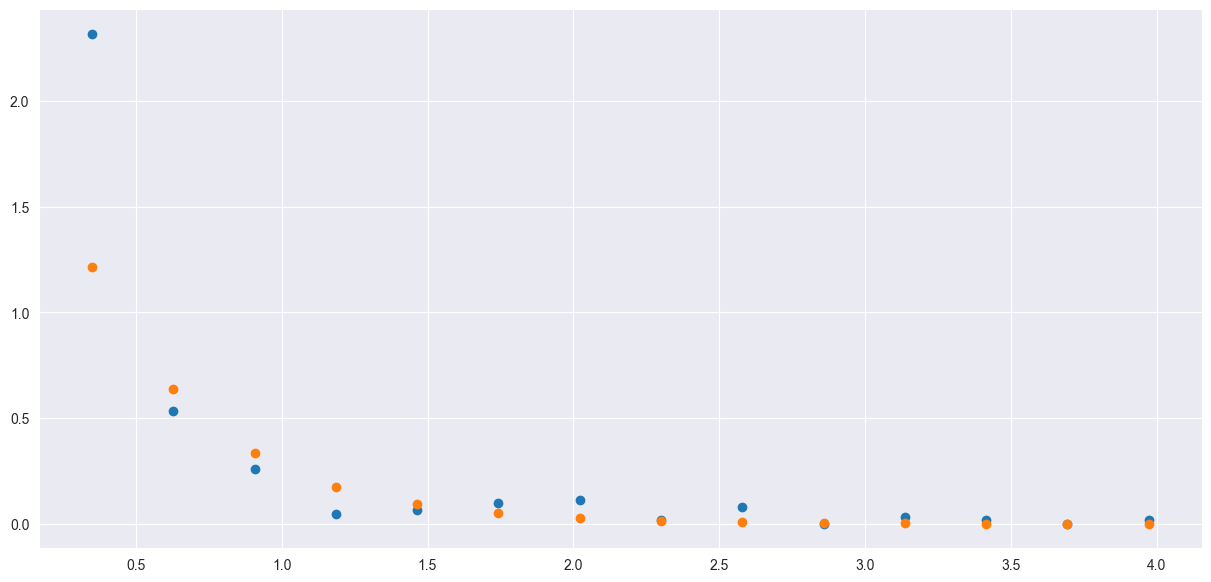

Loc: 0.3495849299935525, scale: 0.43311321660490854
stats: 0.19311674992469952, p-value:9.269673781374634e-08


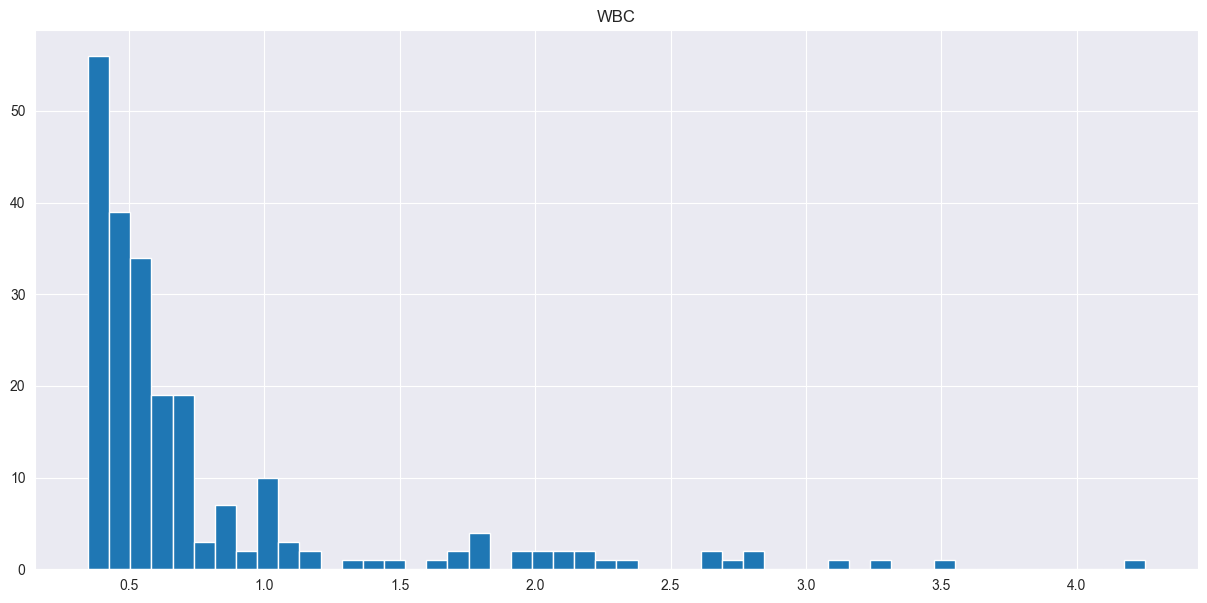

stats: 0.37922470962739846, p-value:2.481348921917112e-29


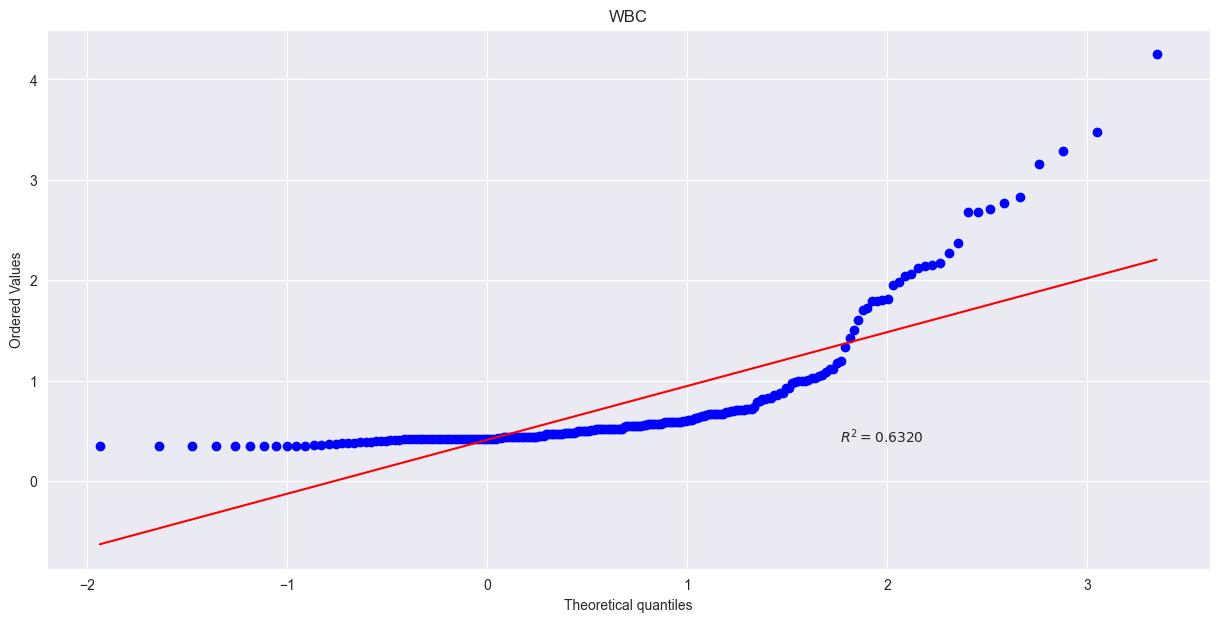

In [6]:
X, y = setupDf("real/WBC_withoutdupl_norm_v10.arff")
endResults = outputResults(X,y)
printResults(endResults)
goodnessOfFit(X,y,32)
ksTestArr(X,y,32,"WBC")
ksTestNorm(X,y,32)
qqPlots(X,y,32,"WBC")

0.5743304530650402 66 [0.3847027644167339, 0.4435645369832858, 0.46308421321461685, 0.4785842282929111, 0.4918222636665887, 0.5073470165710451, 0.5240425754480137, 0.5256285057033647, 0.5403771976613567, 0.5452466620426566, 0.5457443635452086, 0.5445479951523284, 0.5493937819000159, 0.5513688028211489, 0.5525146353691545, 0.5521769051424522, 0.5550014936935036, 0.5546041570856673, 0.5534862429414736, 0.5545952043485799, 0.5542591233102888, 0.5559597899593641, 0.5574884698170249, 0.557671883128143, 0.5584192010765903, 0.5583087054530651, 0.5591237579255285, 0.55697027125851, 0.5548795715502748, 0.555415911181309, 0.5581268235311857, 0.5587811979327659, 0.5579537765472213, 0.5611839476481632, 0.5619874558017507, 0.5635836345850831, 0.5643882029312205, 0.5647254619612337, 0.5645488810021035, 0.5644266054613583, 0.564883312851984, 0.5653648758679444, 0.5641536647793669, 0.5640492947127963, 0.5630561298919641, 0.5646286310416839, 0.5656342825747696, 0.5676055339223921, 0.5710953343988661, 0

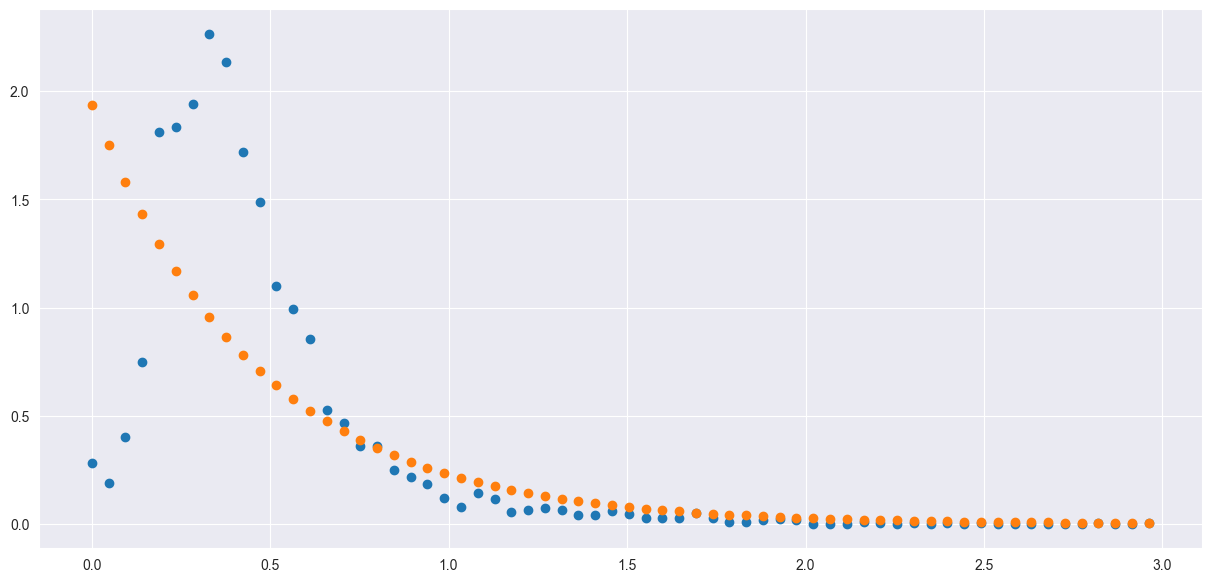

Loc: 0.0007857768723420263, scale: 0.4675661528180032
stats: 0.2558564441411735, p-value:2.6376489475038564e-243


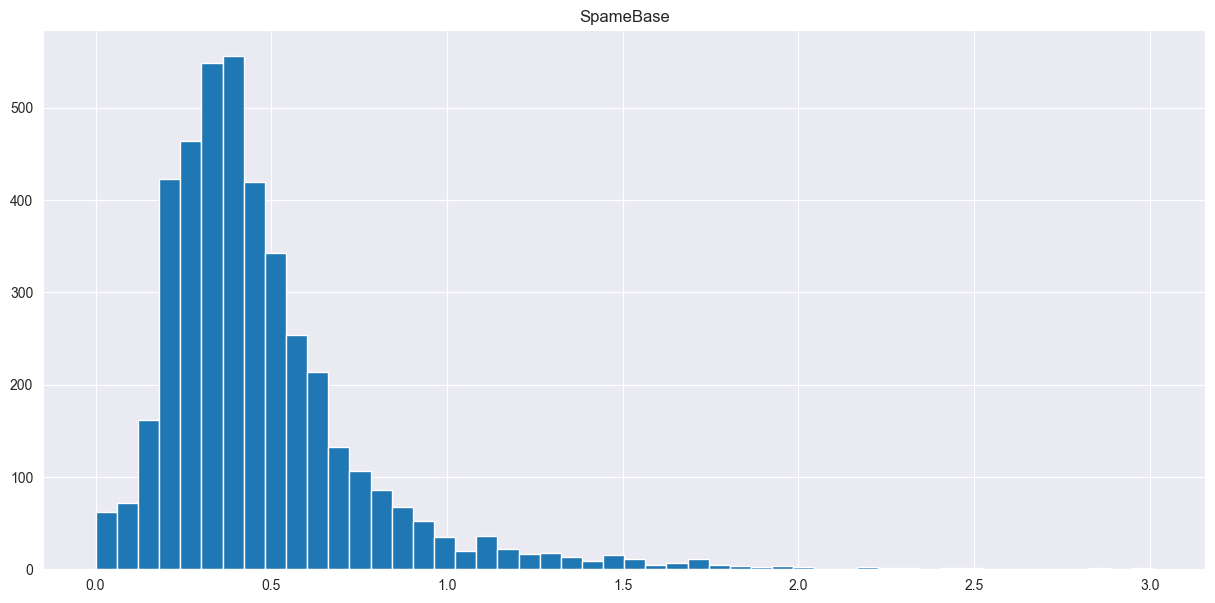

stats: 0.09343820966847027, p-value:2.0421695458125696e-32


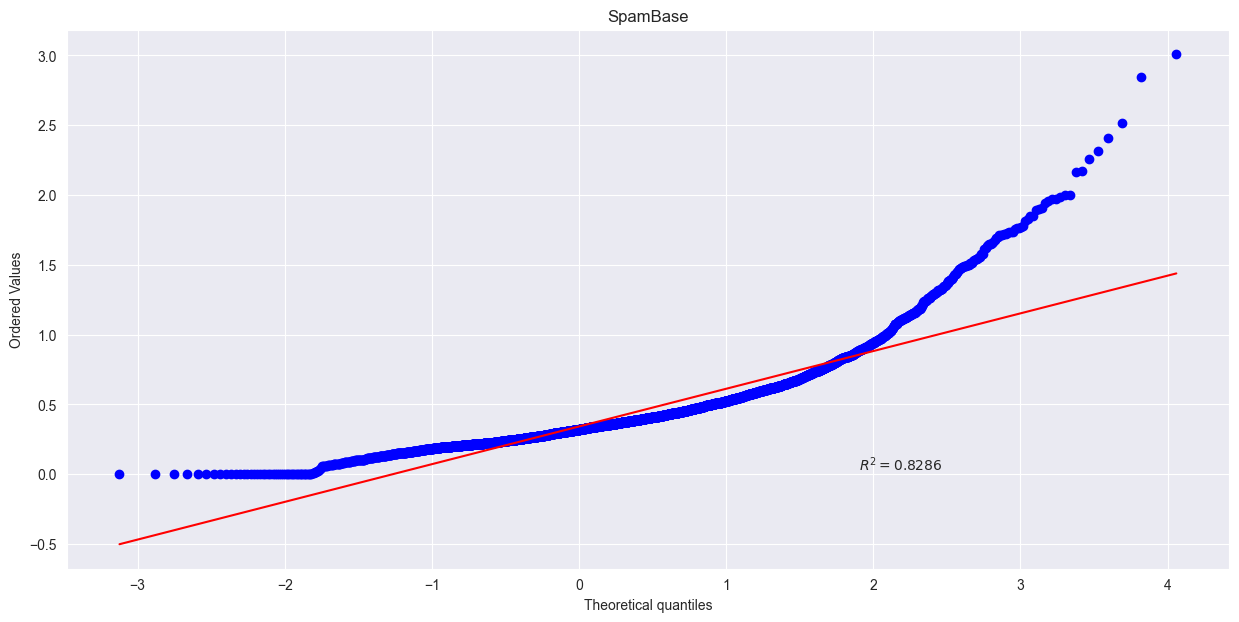

In [7]:
X, y = setupDf("real/SpamBase_withoutdupl_norm_40.arff")
endResults = outputResults(X,y)
printResults(endResults)
goodnessOfFit(X,y,20)
ksTestArr(X,y,20,"SpameBase")
ksTestNorm(X,y,20)
qqPlots(X,y,20,"SpamBase")

0.5410736931097647 14 [0.45047203043539535, 0.4852050162040298, 0.506763421163872, 0.5054248273918557, 0.5207129773143582, 0.5273354938706495, 0.5300831337184727, 0.5353670565027475, 0.5258559954910526, 0.5254332816683105, 0.5326898689587148, 0.5365647456671833, 0.5410736931097647, 0.5391714809074255, 0.5277582076933915, 0.5357897703254895, 0.5236015217697618, 0.5319853459208115, 0.5183175989854868, 0.5159222206566154, 0.5202198111878257, 0.517119909821051, 0.5154995068338734, 0.5140904607580667, 0.5142313653656474, 0.5150063407073412, 0.5144427222770185, 0.5094406087079046, 0.506763421163872, 0.5146540791883893, 0.5072565872904043, 0.5067634211638721, 0.5072565872904042, 0.4998590953924193, 0.5081020149358884, 0.5017613075947582, 0.49873185853177393, 0.4942933633929829, 0.49203888967169224, 0.49682964632943494, 0.4907002958996759, 0.4915457235451599, 0.49457517260814426, 0.4910525574186276, 0.48992532055798227, 0.4926025081020149, 0.4858390869381428, 0.4866845145836269, 0.486261800760

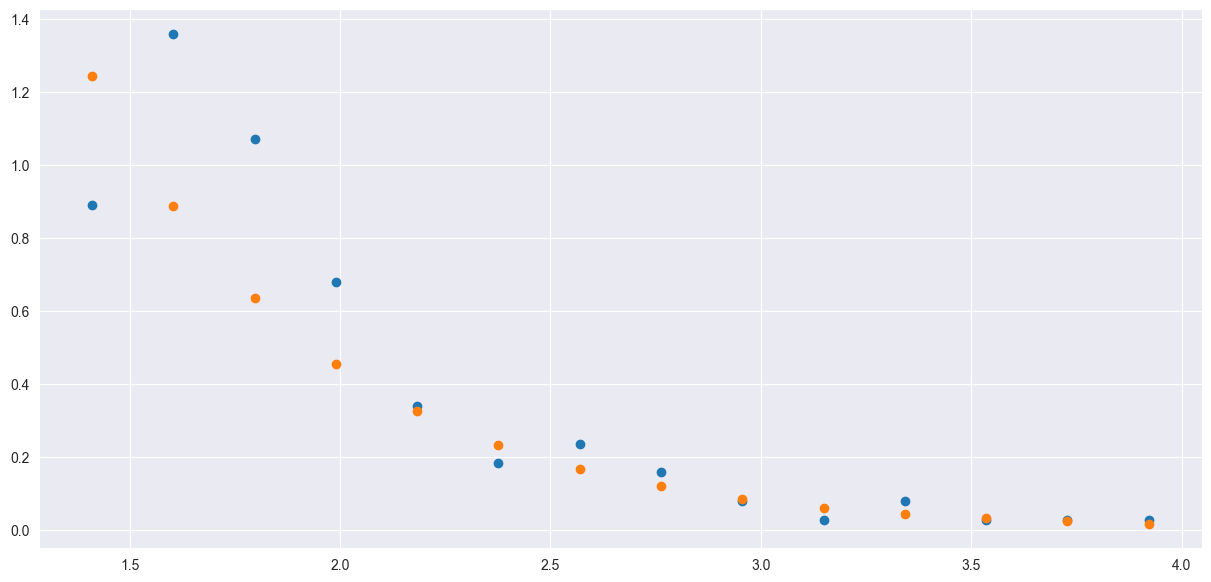

Loc: 1.4102418514497836, scale: 0.5745033667775836
stats: 0.1371304170002114, p-value:0.0010401072843705132


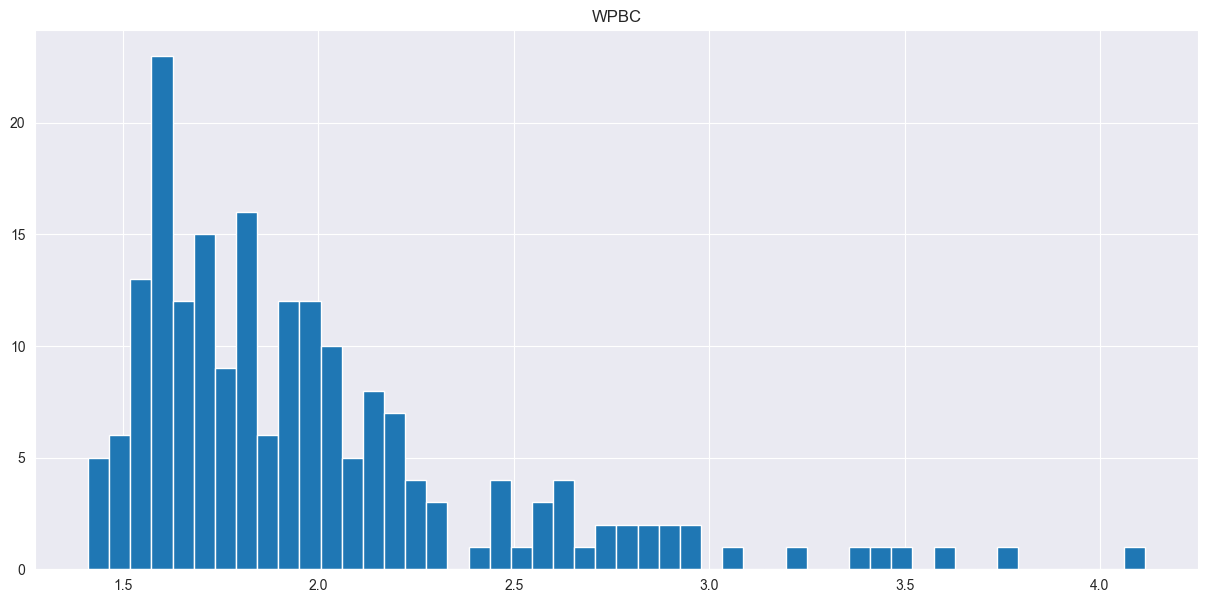

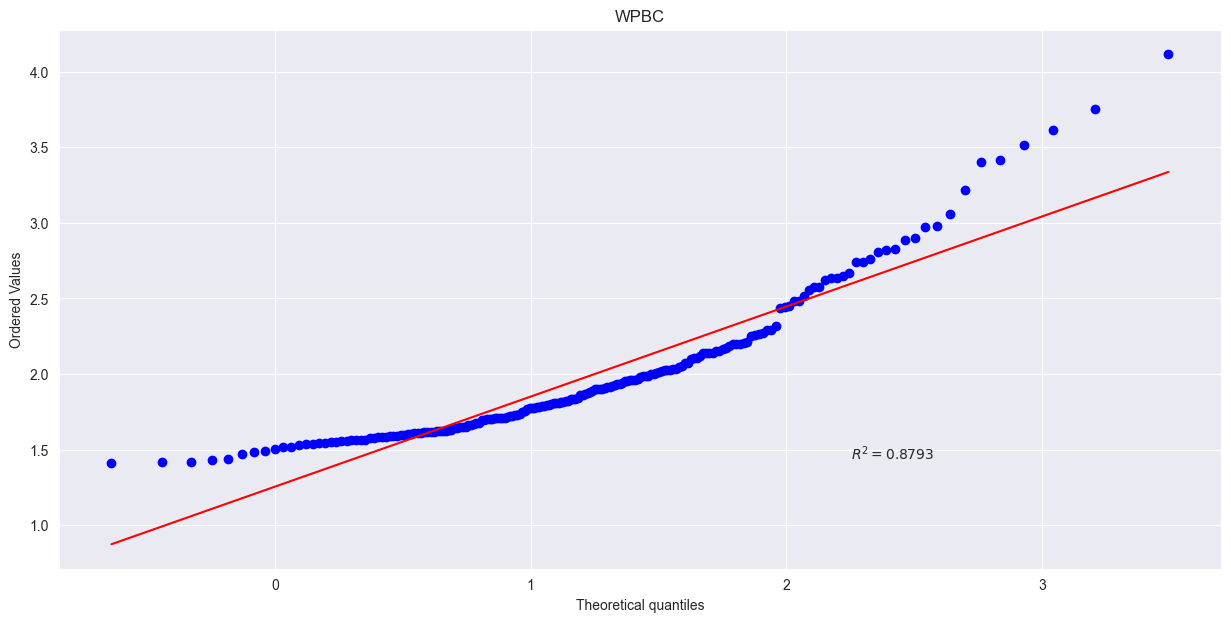

In [8]:
X, y = setupDf("real/WPBC_withoutdupl_norm.arff")
endResults = outputResults(X, y)
printResults(endResults)
goodnessOfFit(X, y, 42)
ksTestArr(X,y,42,"WPBC")
qqPlots(X,y,42,"WPBC")

0.6746388888888889 24 [0.5979444444444444, 0.6125555555555555, 0.593, 0.593, 0.5931111111111111, 0.5901944444444445, 0.5930277777777777, 0.5942222222222222, 0.6036111111111111, 0.613611111111111, 0.6116666666666666, 0.6216666666666666, 0.6221111111111111, 0.6313888888888888, 0.6356666666666666, 0.6434444444444444, 0.6481388888888888, 0.6536666666666666, 0.6600555555555555, 0.6556944444444444, 0.6545, 0.6690555555555555, 0.6746388888888889, 0.6654166666666665, 0.659861111111111, 0.6621111111111111, 0.6636388888888889, 0.6616666666666665, 0.6649444444444444, 0.6630833333333334, 0.6606944444444444, 0.658222222222222, 0.6589999999999999, 0.6545555555555554, 0.6578333333333333, 0.6524999999999999, 0.6430277777777778, 0.6483055555555555, 0.6452499999999999, 0.645611111111111, 0.6438611111111111, 0.6443333333333332, 0.6447499999999999, 0.6431944444444443, 0.6441111111111112, 0.6448333333333333, 0.650361111111111, 0.6528611111111111, 0.6521111111111111, 0.6555, 0.6543055555555556, 0.6544444444

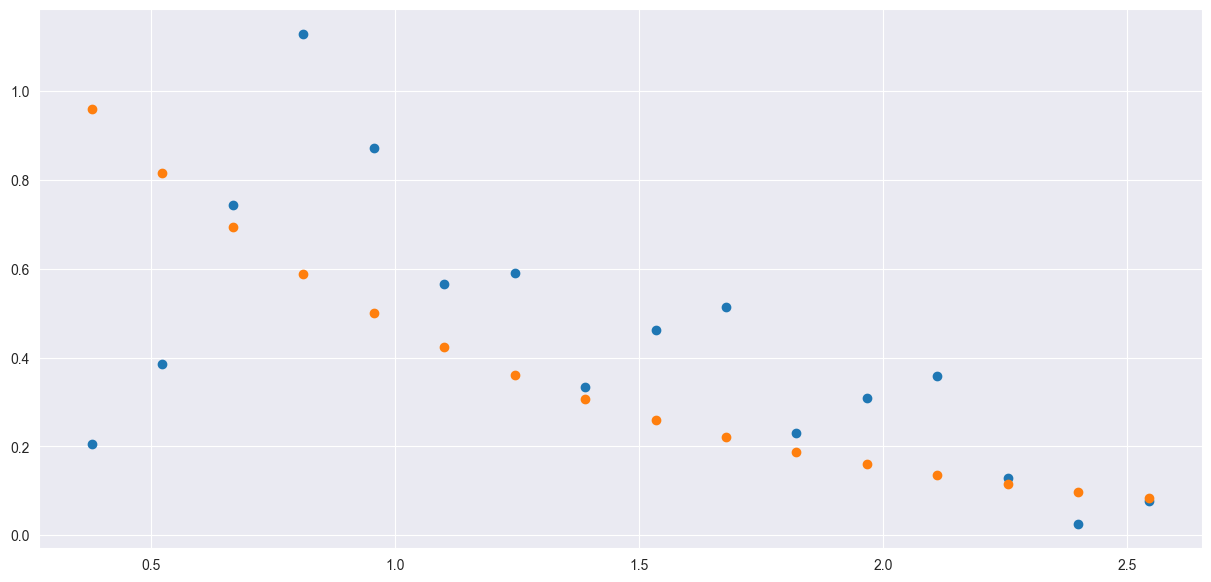

Loc: 0.378757995940565, scale: 0.8843238956869015
stats: 0.21750524751226377, p-value:1.0767017063527005e-11


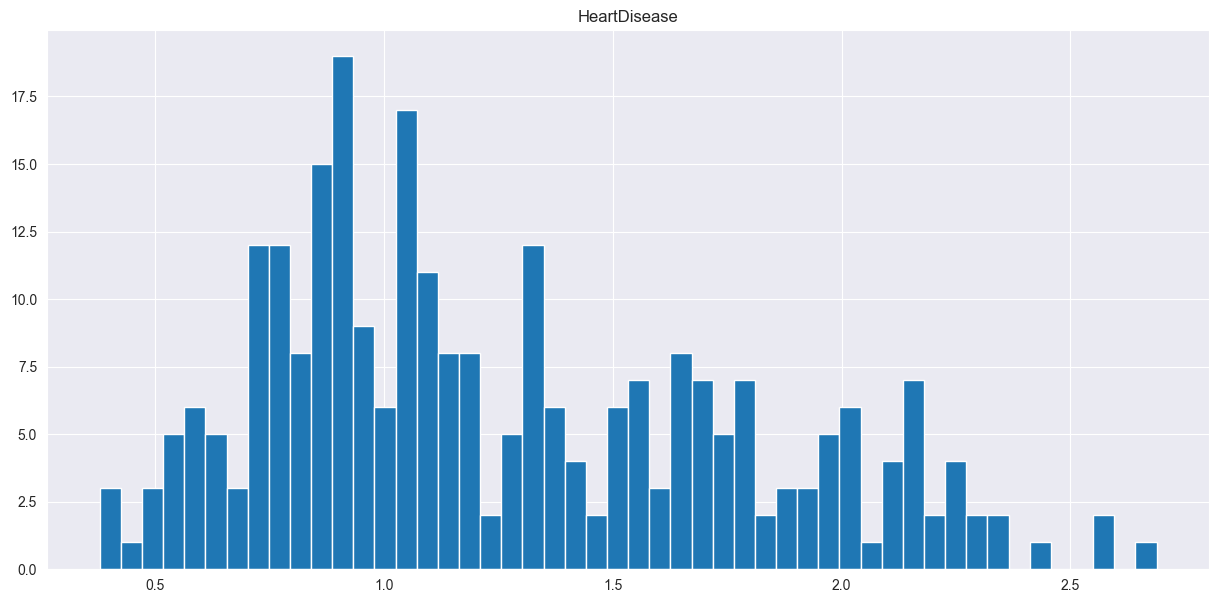

stats: 0.04952021226563741, p-value:0.5062174254912717


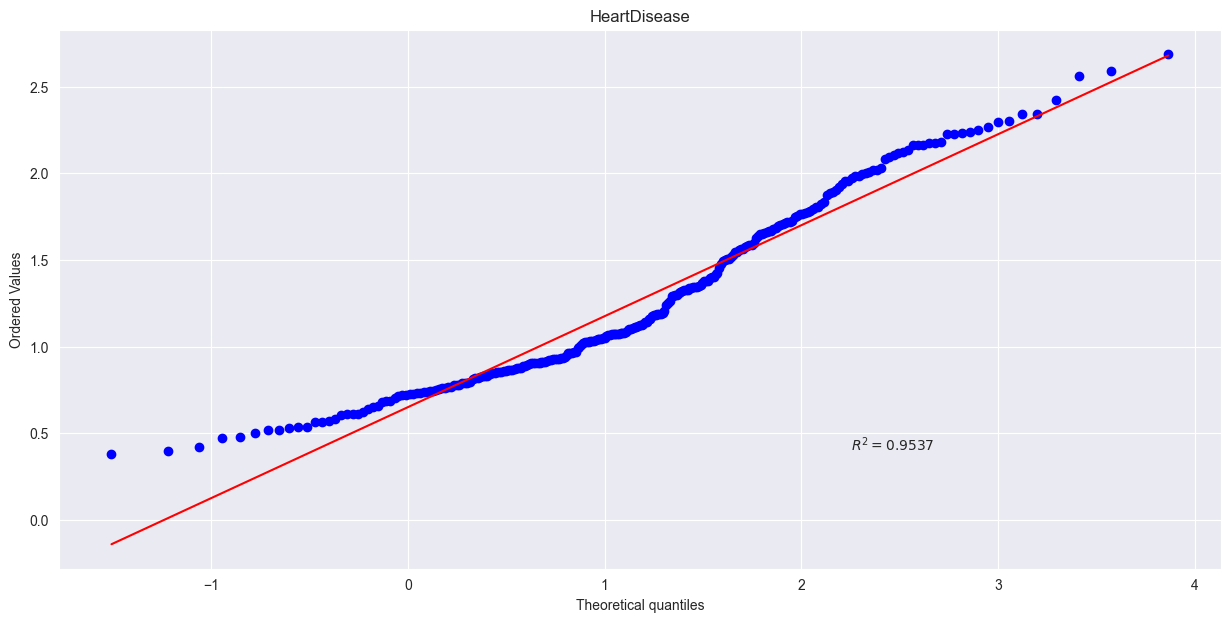

In [9]:
X, y = setupDf("real/HeartDisease_withoutdupl_norm_44.arff")
endResults = outputResults(X, y)
printResults(endResults)
goodnessOfFit(X, y, 5)
ksTestArr(X,y,5,"HeartDisease")
ksTestNorm(X,y,5)
qqPlots(X,y,5,"HeartDisease")

In [10]:
X, y = setupDf("real/Glass_withoutdupl_norm.arff")
endResults = outputResults(X, y)
printResults(endResults)
goodnessOfFit(X, y, 63)
ksTestArr(X,y,63,"Glass")
ksTestNorm(X,y,63)
qqPlots(X,y,63,"Glass")

ValueError: The data contains non-finite values.

0.7921928817451206 36 [0.6010332950631458, 0.6314580941446613, 0.6262916188289323, 0.6687715269804823, 0.6888633754305395, 0.6733639494833524, 0.711825487944891, 0.6951779563719863, 0.6969001148105627, 0.7215843857634903, 0.71699196326062, 0.7210103329506314, 0.7227324913892078, 0.7278989667049368, 0.7531572904707232, 0.751435132032147, 0.7319173363949483, 0.7451205510907002, 0.756601607347876, 0.7686567164179104, 0.761768082663605, 0.7686567164179104, 0.7784156142365098, 0.7864523536165328, 0.7847301951779564, 0.7784156142365097, 0.7841561423650976, 0.7784156142365097, 0.7663605051664754, 0.7640642939150402, 0.7640642939150402, 0.7600459242250287, 0.7669345579793342, 0.7761194029850745, 0.7921928817451206, 0.7766934557979335, 0.7761194029850745, 0.7680826636050516, 0.7508610792192882, 0.7588978185993112, 0.7548794489092996, 0.7399540757749714, 0.7468427095292767, 0.7497129735935706, 0.7497129735935706, 0.7456946039035591, 0.7376578645235361, 0.7571756601607349, 0.7445464982778416, 0.7

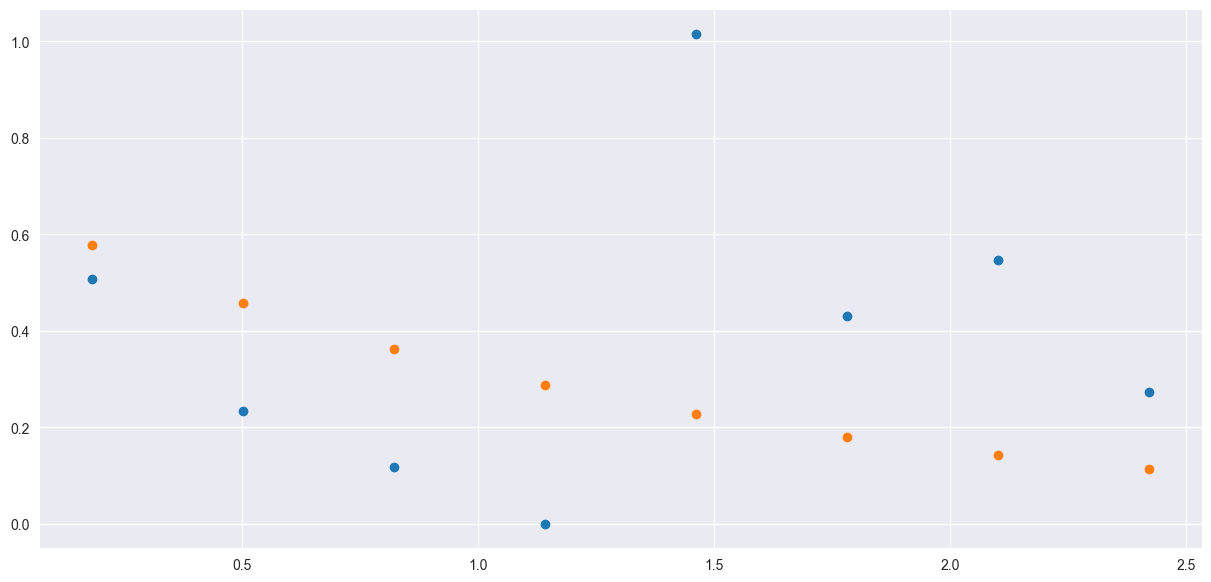

Loc: 0.18180961633193196, scale: 1.3704770564935853
stats: 0.3521249349799569, p-value:2.241496928225167e-09


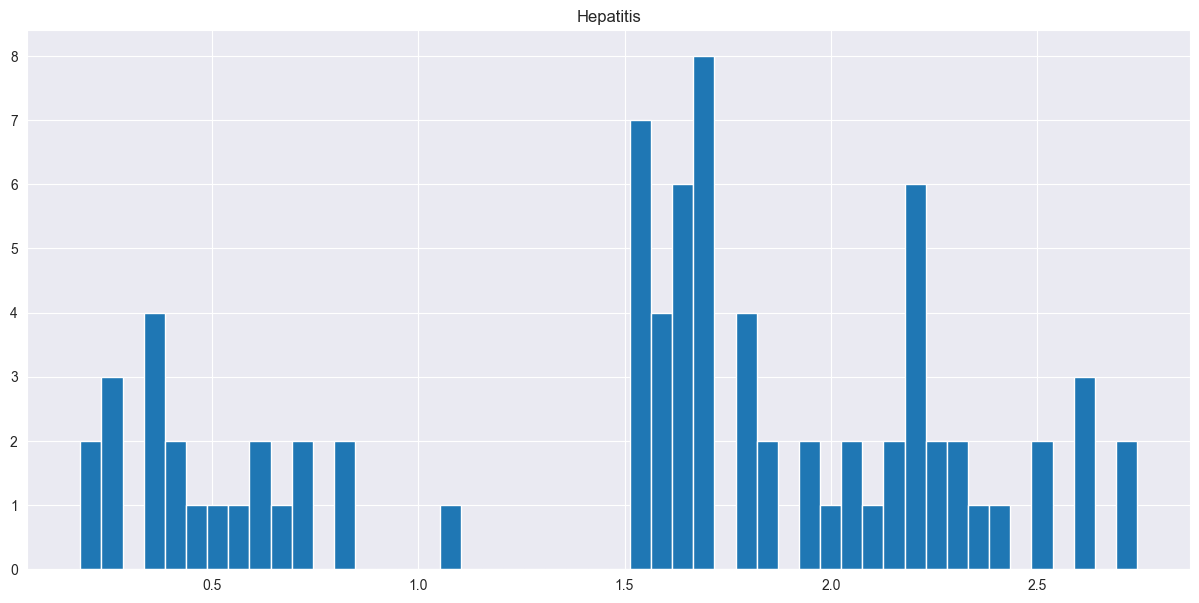

stats: 0.15088822682165676, p-value:0.04692520041546755


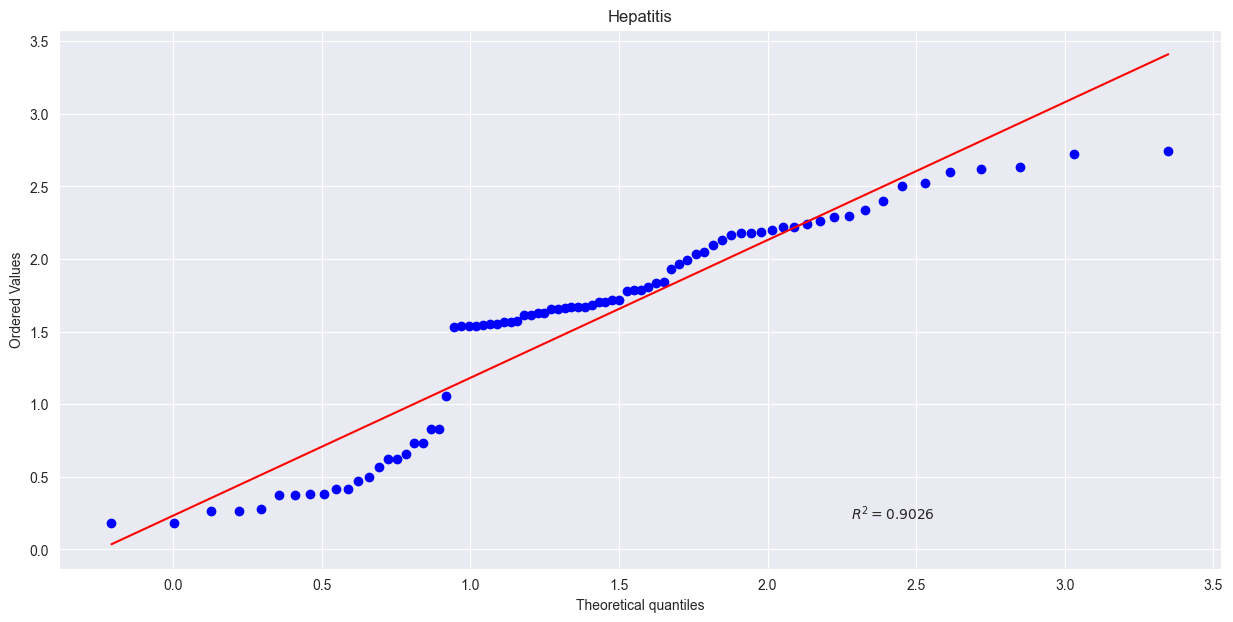

In [16]:
X, y = setupDf("real/Hepatitis_withoutdupl_norm_16.arff")
endResults = outputResults(X, y)
printResults(endResults)
goodnessOfFit(X, y, 2)
ksTestArr(X,y,2,"Hepatitis")
ksTestNorm(X,y,2)
qqPlots(X,y,2,"Hepatitis")

0.728936567164179 68 [0.6832388059701493, 0.7028544776119403, 0.7065783582089552, 0.7067201492537313, 0.7086492537313432, 0.7166380597014925, 0.7182761194029851, 0.7212126865671643, 0.7146380597014926, 0.7183992537313433, 0.718723880597015, 0.7199701492537313, 0.7229291044776118, 0.7208880597014925, 0.7201791044776119, 0.7203432835820895, 0.7182910447761194, 0.7189776119402984, 0.719347014925373, 0.7202873134328358, 0.7225671641791044, 0.7232276119402985, 0.723365671641791, 0.7224402985074627, 0.7233694029850746, 0.7247835820895523, 0.7262574626865671, 0.7242014925373134, 0.7234626865671642, 0.723597014925373, 0.7240634328358208, 0.7242985074626865, 0.7243955223880596, 0.7239253731343284, 0.7243805970149254, 0.7228395522388059, 0.7244850746268656, 0.7258171641791046, 0.725723880597015, 0.7261753731343286, 0.7267611940298506, 0.7264589552238805, 0.7269029850746268, 0.7267873134328359, 0.7277537313432835, 0.7278955223880597, 0.726768656716418, 0.7268582089552239, 0.7266492537313434, 0.72

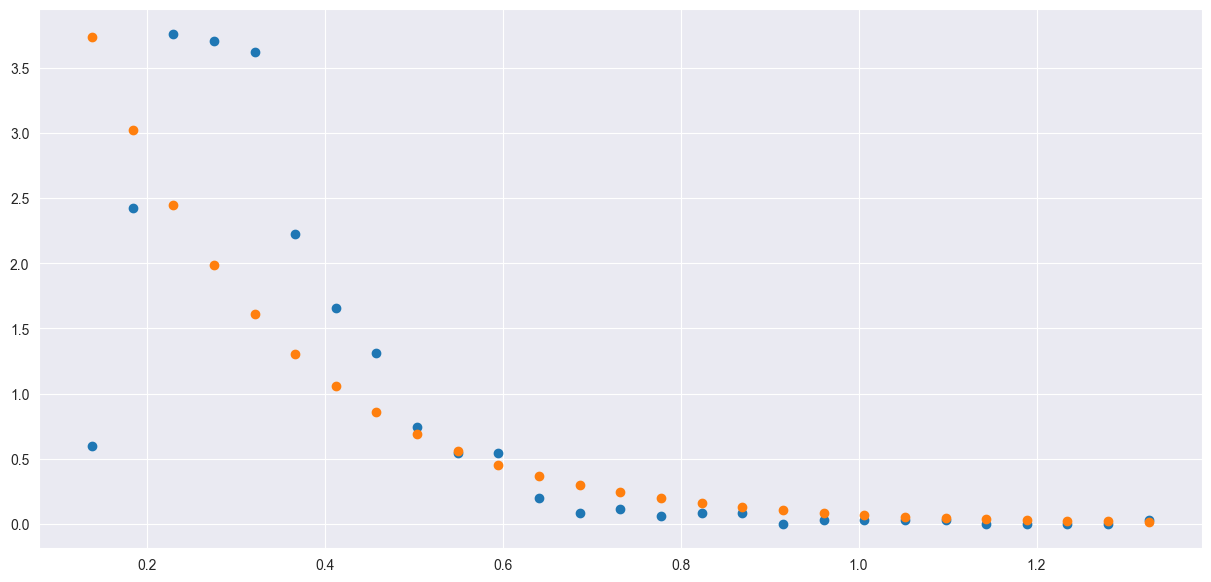

Loc: 0.13840441052224262, scale: 0.21684105970989703
stats: 0.2092573773614875, p-value:5.582453072235402e-30


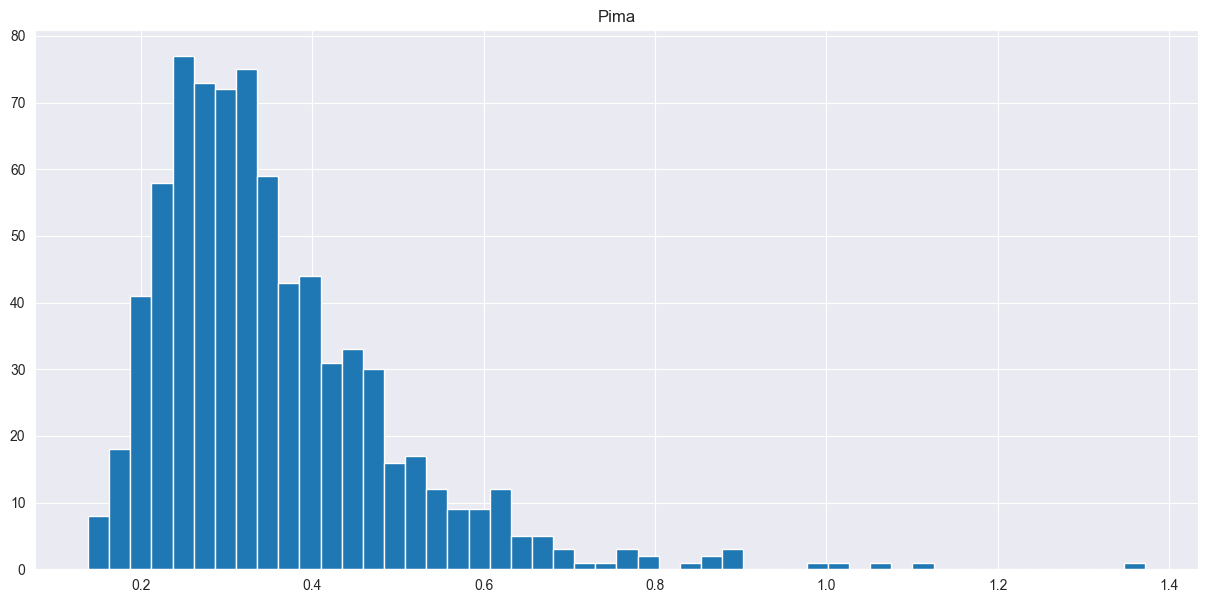

stats: 0.06330663781614843, p-value:0.004051421712574387


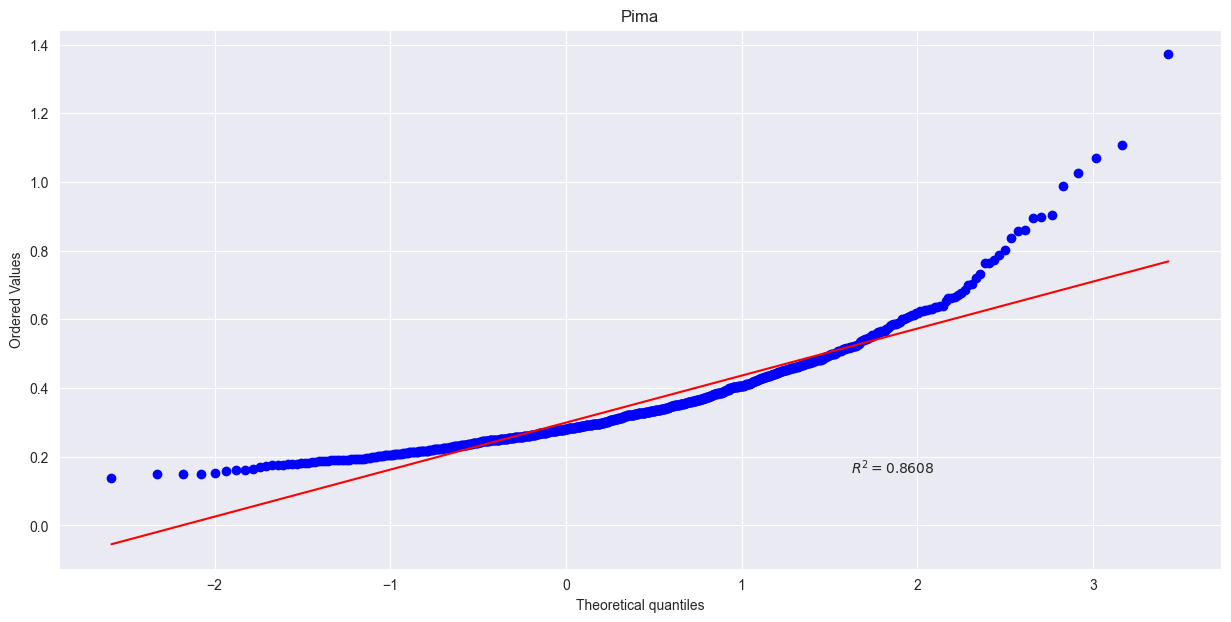

In [17]:
X, y = setupDf("real/Pima_withoutdupl_norm_35.arff")
endResults = outputResults(X, y)
printResults(endResults)
goodnessOfFit(X, y, 3)
ksTestArr(X,y,3,"Pima")
ksTestNorm(X,y,3)
qqPlots(X,y,3,"Pima")

0.9705904752233955 17 [0.9149015028432169, 0.962774167343623, 0.9633174248578391, 0.9688312347684808, 0.968389520714866, 0.9704508529650689, 0.96963850528026, 0.9692323314378555, 0.9685875304630382, 0.9692907189277009, 0.9703213850528026, 0.9704330828594638, 0.9698339764419172, 0.9701208367181153, 0.9705016246953697, 0.9705904752233955, 0.9703924654752234, 0.9705143176279447, 0.9702046100731113, 0.9703797725426483, 0.9699939073923638, 0.9687093826157596, 0.9678361088545898, 0.9687652315190901, 0.9687398456539398, 0.9684428310316815, 0.968133123476848, 0.9668308285946385, 0.9666582047116166, 0.9664145004061739, 0.9667749796913078, 0.9665922014622259, 0.9663941917140536, 0.9665058895207147, 0.9658966287571079, 0.9651477457351747, 0.9649751218521527, 0.9645207148659627, 0.9655615353371244, 0.965178208773355, 0.9651223598700245, 0.9651629772542648, 0.9650918968318439, 0.9651858245329001, 0.9650995125913892, 0.9653965272136474, 0.9642567018683996, 0.964642567018684, 0.9643582453290007, 0.96

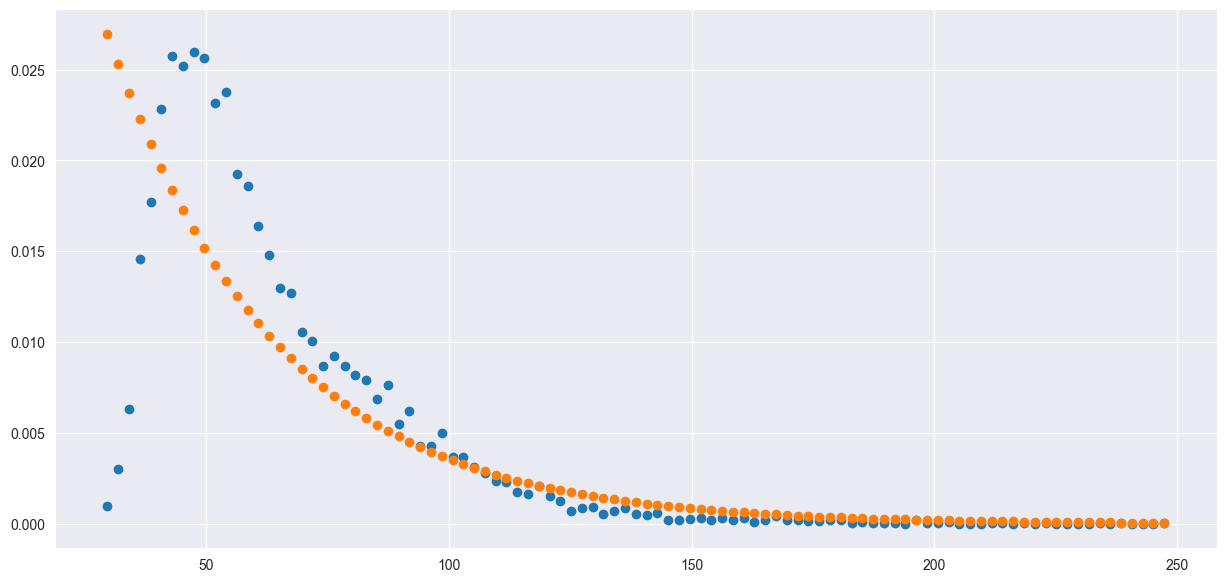

Loc: 29.627164969531574, scale: 34.78829127861681
stats: 0.17996505210740188, p-value:4.181037939901658e-280


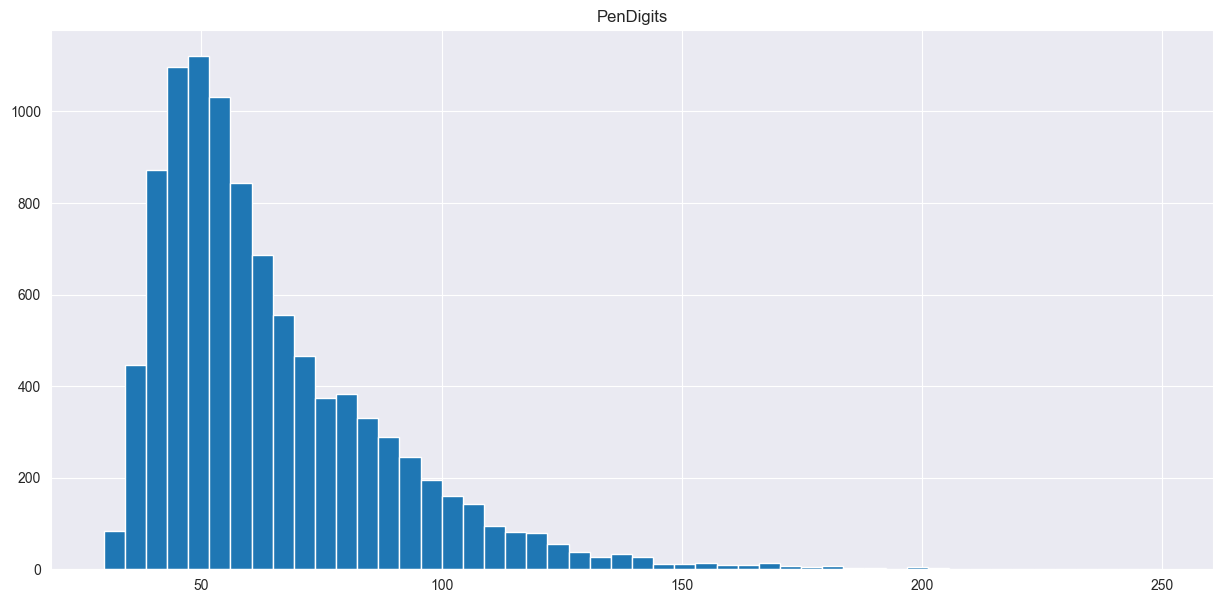

stats: 0.07317360573135961, p-value:2.150088802243422e-46


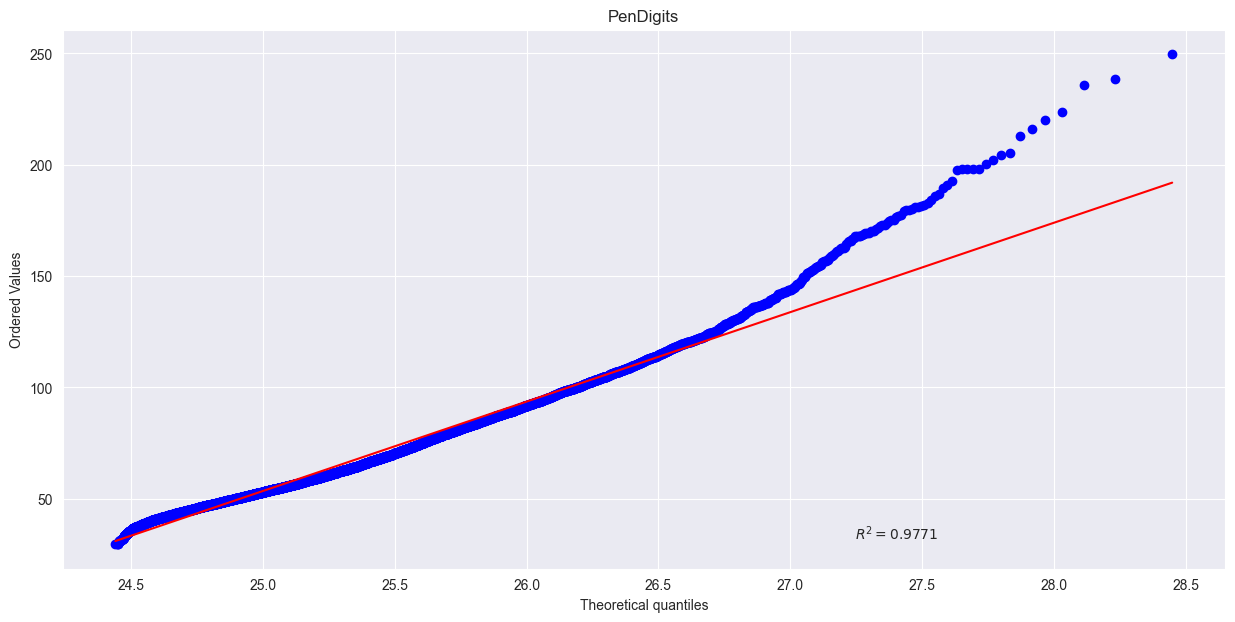

In [18]:
X, y = setupDf("real/PenDigits_withoutdupl_norm_v10.arff")
endResults = outputResults(X, y)
printResults(endResults)
goodnessOfFit(X, y, 20)
ksTestArr(X,y,20,"PenDigits")
ksTestNorm(X,y,20)
qqPlots(X,y,20,"PenDigits")

In [19]:
X, y = setupDf("clusters/artificial/cluto-t4-8k.arff")
endResults = outputResultsArt(X, y,checkValue=6)
printResults(endResults)
goodnessOfFit(X, y, 11)

NameError: name 'outputResultsArt' is not defined

0.9052390057361377 28 [0.7202054578685321, 0.7655913978494623, 0.8081918081918081, 0.8235397607318792, 0.7730068337129841, 0.7724649327878433, 0.7800872291127166, 0.8051078011290212, 0.837789661319073, 0.8042237442922374, 0.7739212007504691, 0.7738017429193899, 0.760132058287796, 0.7991530550514216, 0.8453703703703705, 0.8587752907172145, 0.8722965666396324, 0.8828228148930554, 0.9016635279347144, 0.8948883833357031, 0.8737520982418943, 0.8817103620474407, 0.883533447684391, 0.8903537774838816, 0.8989961389961392, 0.8981349206349207, 0.9052390057361377, 0.891990926539871, 0.8848358760980121, 0.884373828271466, 0.8871885017061315, 0.8894842954159593, 0.8843137254901959, 0.8568271119842829, 0.8578882207286878, 0.8708081824279008, 0.8706317204301075, 0.8635352498288844, 0.8656212484993997, 0.8370020964360586, 0.8456638902498774, 0.8463487071977637, 0.8454016913319238, 0.8477256574271499, 0.8517303591930457, 0.8497118592659995, 0.8546405823475886, 0.8675847457627117, 0.8544420753375978, 0.

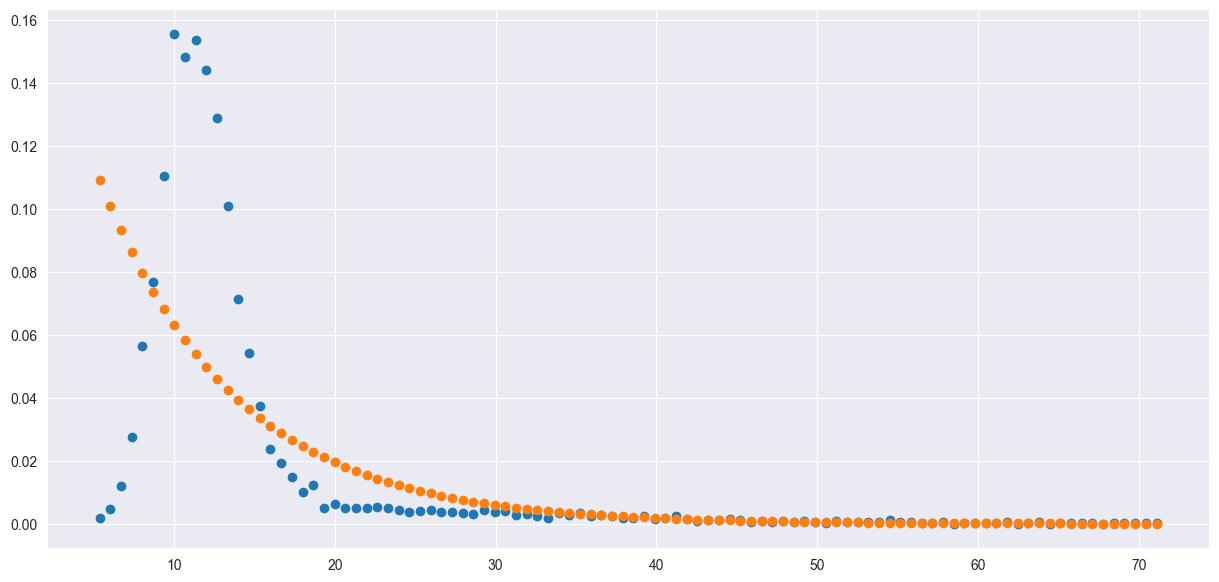

In [324]:
X, y = setupDf("clusters/artificial/cluto-t7-10k.arff")
endResults = outputResultsArt(X, y,checkValue=9)
printResults(endResults)
goodnessOfFit(X, y, 11)

0.8941937259218493 21 [0.7795337995337996, 0.8460370370370369, 0.8563144329896906, 0.8743589743589744, 0.8749240121580546, 0.8463860617560808, 0.8379679144385027, 0.8635697844737393, 0.8668252080856124, 0.8697874899759422, 0.8626056024899957, 0.851123595505618, 0.8633785061456036, 0.8408189033189033, 0.8693602071005916, 0.8817095588235295, 0.880363321799308, 0.8571005917159763, 0.8571330589849109, 0.8941937259218493, 0.8800105485232067, 0.8779617834394904, 0.8787802419354839, 0.85884995507637, 0.8660906298003072, 0.8696700037078235, 0.8656367041198502, 0.861492673992674, 0.8630421865715983, 0.8577004219409282, 0.8560550006165989, 0.8399733954107084, 0.8576728609889028, 0.8563191418035535, 0.859005177514793, 0.8587724377533295, 0.8518189884649512, 0.8522365196078432, 0.850630733944954, 0.8570620555914674, 0.8617504542701393, 0.8560812860175917, 0.8504505759940544, 0.8488417406365015, 0.8499145299145302, 0.848509595753369, 0.8572070312499999, 0.8548762558196521, 0.855938553765455, 0.8498

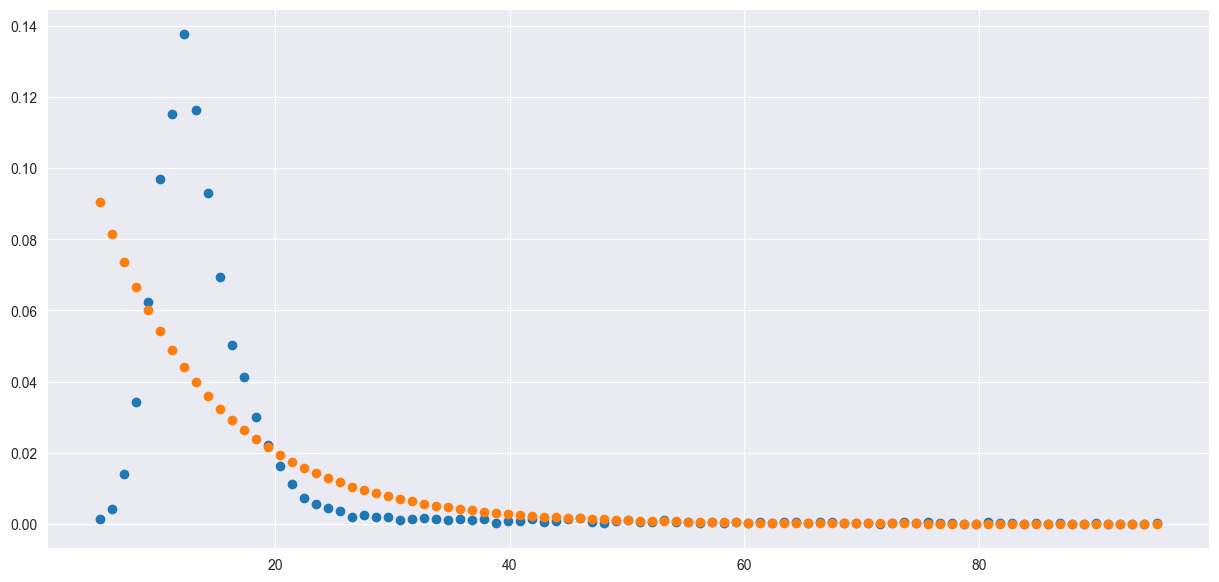

In [325]:
X, y = setupDf("clusters/artificial/cluto-t8-8k.arff")
endResults = outputResultsArt(X, y,checkValue=8)
printResults(endResults)
goodnessOfFit(X, y, 11)